<a href="https://colab.research.google.com/github/VattamYasritha/Machine_Learning/blob/main/Experiment%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
],dtype=float)

y = np.array([
    [0],
    [1],
    [1],
    [0]
],dtype=float)

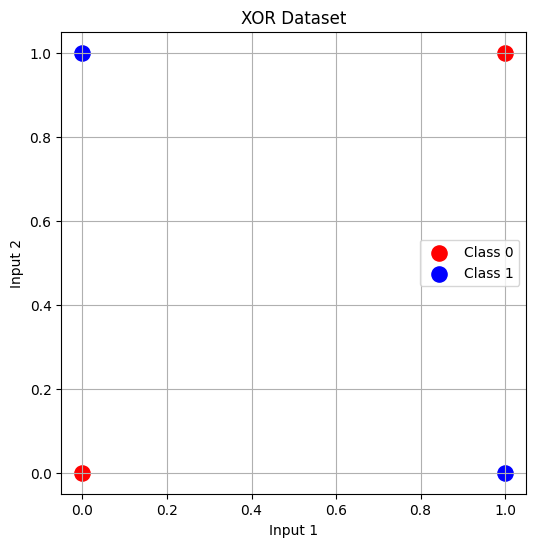

In [3]:
plt.figure(figsize=(6,6))

for i in range(len(X)):

    if y[i]==0:
        plt.scatter(X[i][0],X[i][1],
                    color="red",
                    s=120,
                    label="Class 0" if i==0 else "")
    else:
        plt.scatter(X[i][0],X[i][1],
                    color="blue",
                    s=120,
                    label="Class 1" if i==1 else "")

plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("XOR Dataset")

plt.legend()

plt.grid(True)

plt.show()

In [4]:
model=Sequential()

model.add(Dense(
    4,
    input_dim=2,
    activation="sigmoid"
))

model.add(Dense(
    1,
    activation="sigmoid"
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [6]:
history=model.fit(
    X,
    y,
    epochs=500,
    verbose=0
)

In [7]:
prediction=model.predict(X)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
[[0.4617268 ]
 [0.49504122]
 [0.5010353 ]
 [0.5271223 ]]


In [8]:
prediction=(prediction>0.5).astype(int)

print(prediction)

[[0]
 [0]
 [1]
 [1]]


In [9]:
loss,accuracy=model.evaluate(X,y,verbose=0)

print("Accuracy =",accuracy*100,"%")

Accuracy = 50.0 %


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


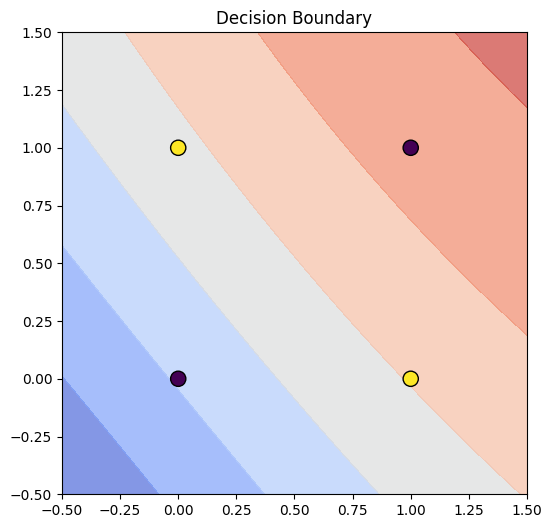

In [10]:
xx,yy=np.meshgrid(
    np.linspace(-0.5,1.5,200),
    np.linspace(-0.5,1.5,200)
)

grid=np.c_[xx.ravel(),yy.ravel()]

Z=model.predict(grid)

Z=Z.reshape(xx.shape)

plt.figure(figsize=(6,6))

plt.contourf(xx,yy,Z,
             alpha=0.7,
             cmap="coolwarm")

plt.scatter(
    X[:,0],
    X[:,1],
    c=y.flatten(),
    edgecolors="black",
    s=120
)

plt.title("Decision Boundary")

plt.show()

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53 (216.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 36 (148.00 B)